--- DATA COLUMNS & TYPES ---
STATE_CODE       int32
DISTRICT           str
GaPa_NaPa          str
Type_GN            str
Province           str
geometry      geometry
dtype: object

--- FIRST 5 ROWS OF DATA ---
   STATE_CODE   DISTRICT        GaPa_NaPa     Type_GN Province
0           1  TAPLEJUNG  Aathrai Tribeni  Gaunpalika        1
1           1  TAPLEJUNG       Maiwakhola  Gaunpalika        1
2           1  TAPLEJUNG        Meringden  Gaunpalika        1
3           1  TAPLEJUNG       Mikwakhola  Gaunpalika        1
4           1  TAPLEJUNG     Phaktanglung  Gaunpalika        1

--- COORDINATE SYSTEM ---
EPSG:4326

--- GENERATING MAP PREVIEW ---


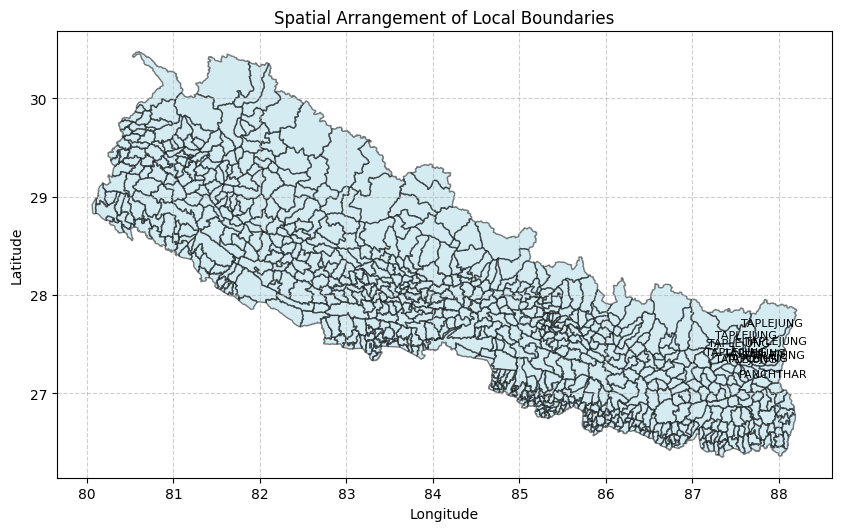

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt

def analyze_json_structure(file_path):
    # Load the file
    try:
        gdf = gpd.read_file(file_path)
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    # 1. Print the Attribute Table (The Schema)
    print("--- DATA COLUMNS & TYPES ---")
    print(gdf.dtypes)
    print("\n--- FIRST 5 ROWS OF DATA ---")
    # We drop the 'geometry' column for a cleaner text print of the attributes
    print(gdf.drop(columns='geometry').head())

    # 2. Check the Coordinate Reference System (CRS)
    print(f"\n--- COORDINATE SYSTEM ---")
    print(gdf.crs)

    # 3. Visual Arrangement (The Map)
    print("\n--- GENERATING MAP PREVIEW ---")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the boundaries
    gdf.plot(ax=ax, edgecolor='black', color='lightblue', alpha=0.5)
    
    # Label the first few features to show how they are arranged
    # We use representative_point() to ensure labels stay inside the polygons
    for idx, row in gdf.head(10).iterrows():
        # Change 'DISTRICT' to whatever your actual column name is
        label_col = next((c for c in ['DISTRICT', 'district', 'PR_NAME', 'local_level'] if c in gdf.columns), None)
        if label_col:
            plt.annotate(text=row[label_col], xy=(row.geometry.representative_point().x, 
                                                 row.geometry.representative_point().y),
                         horizontalalignment='center', fontsize=8)

    plt.title("Spatial Arrangement of Local Boundaries")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Execution
analyze_json_structure("localboundries.json")

In [14]:
import geopandas as gpd
from shapely.geometry import Point

def get_nepal_location(lat, lon):
    file_path = "localboundries.json"
    gdf = gpd.read_file(file_path)

    # Standardize CRS
    if gdf.crs is None or gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    province_map = {
        1: "Koshi", 2: "Madhesh", 3: "Bagmati", 
        4: "Gandaki", 5: "Lumbini", 6: "Karnali", 7: "Sudurpashchim"
    }

    point = Point(lon, lat)
    match = gdf[gdf.contains(point)]

    if not match.empty:
        res = match.iloc[0]
        
        # --- Robust Province Handling ---
        p_val = res['Province']
        
        # If it's a number (or a string that looks like a number)
        try:
            p_name = province_map.get(int(p_val), str(p_val))
        except ValueError:
            # If it's already a name like "Karnali", use it as is
            p_name = str(p_val)

        print(f"\n--- Location Found ---")
        print(f"Province:     {p_name}")
        print(f"District:     {res['DISTRICT']}")
        print(f"Sub-Division: {res['GaPa_NaPa']} ({res['Type_GN']})")
    else:
        print("\nNo match found in the boundary file.")

# Use the improved input logic from before
user_input = input("Enter coordinates (Lat, Lon): ")
try:
    parts = [p.strip() for p in user_input.split(',')]
    get_nepal_location(float(parts[0]), float(parts[1]))
except Exception as e:
    print(f"Error: {e}")

Enter coordinates (Lat, Lon):  27.815939976506673, 84.94069829788793



--- Location Found ---
Province:     Bagmati
District:     DHADING
Sub-Division: Galchi (Gaunpalika)
